# Case Study 4: Spam Detection

## Business Problem

Email and messaging platforms receive a large number of messages every
day. Some messages are unwanted spam, advertisements, scams, or
promotional messages.

A company wants to automatically identify whether a message is spam or
legitimate (ham).

## Problem Type

**Classification**

This is a supervised learning problem because the dataset contains
predefined labels indicating whether a message is spam or ham.

## Business Objective

Build a Machine Learning model that can classify incoming messages as
Spam or Ham and help reduce unwanted messages.

## Success Metrics

- Accuracy
- Precision
- Recall
- F1-Score

Special attention will be given to **Precision and Recall**, because
incorrectly classifying legitimate messages as spam can negatively
affect users.

In [1]:
import pandas as pd

# Load SMS Spam Collection dataset
df = pd.read_csv(
    r"C:\Users\admin\SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

# Display first 5 rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\admin\\SMSSpamCollection'

In [2]:
import os

print(os.listdir(r"C:\Users\admin\Downloads"))

['.opera', '03_Python_Functions_Complete_Notes.ipynb', '04_Python_OOP_Complete_Notes.ipynb', '05_Python_File_Exception_Modules_Notes.ipynb', '1_Read_CSV_TSV_Excel_JSON_from_Drive.ipynb', '3_Fetch_Data_from_Local_PostgreSQL_pgAdmin.ipynb', 'Advanced_Notes_and_Password_Manager_Synopsis (1).pdf', 'Advanced_Notes_and_Password_Manager_Synopsis.pdf', 'allmovieland.apk', 'Antigravity-x64.exe', 'archive.zip', 'bde51abc-7584-4fdc-9e57-aafa9b04751f~1.jpg', 'Black and White Clean Professional A4 Resume.pdf', 'boy.jpg', 'burger.jpg', 'ChatGPT Image Jun 26, 2026, 09_10_53 PM.png', 'ChatGPT Image Jun 27, 2026, 06_14_16 PM.png', 'ChatGPT Installer.exe', 'ChromeSetup (1).exe', 'ChromeSetup.exe', 'CHUDU Catalog (1).pdf', 'CHUDU Catalog.pdf', 'deepseek_javascript_20251128_8c87ba.js', 'deepseek_text_20251203_bf1ff5.txt', 'Delinquency_prediction_dataset.xlsx', 'demon-slayer-wallpaper-9.webp', 'desktop.ini', 'dfc.pdf', 'doc.pdf', 'Documents - Shortcut.lnk', 'e7ca4dda097794b16769b78ef0e1b138.jpg', 'EDA_Summ

In [3]:
import os

print(os.listdir(r"C:\Users\admin\Downloads\sms+spam+collection"))

['readme', 'SMSSpamCollection']


In [4]:
import pandas as pd

# Load SMS Spam Collection dataset
df = pd.read_csv(
    r"C:\Users\admin\Downloads\sms+spam+collection\SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

# Display first 5 rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (5572, 2)


In [6]:
print("Columns:", df.columns.tolist())

Columns: ['label', 'message']


In [7]:
print(df["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [9]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
label      0
message    0
dtype: int64


In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 403


In [11]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (5169, 2)


label
ham     4516
spam     653
Name: count, dtype: int64


NameError: name 'plt' is not defined

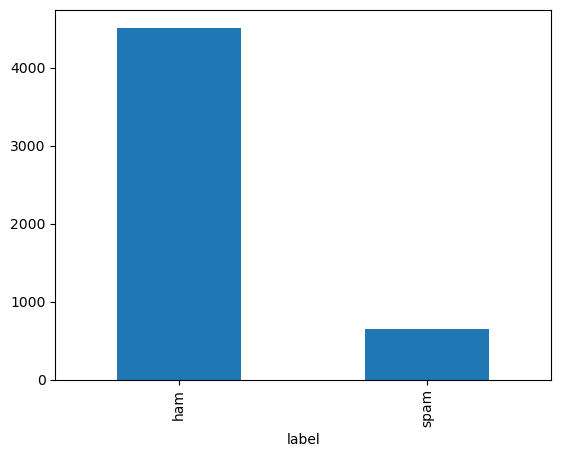

In [12]:
print(df["label"].value_counts())

df["label"].value_counts().plot(kind="bar")

plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.title("Spam vs Ham Messages")

plt.show()

In [13]:
import matplotlib.pyplot as plt

In [14]:
# Convert labels into numerical values
# ham = 0, spam = 1

df["label_encoded"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,label_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [15]:
X = df["message"]
y = df["label_encoded"]

print("Number of messages:", len(X))
print("Target values:", y.value_counts().to_dict())

Number of messages: 5169
Target values: {0: 4516, 1: 653}


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4135
Testing messages: 1034


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (4135, 5000)
Testing TF-IDF Shape: (1034, 5000)


In [18]:
from sklearn.naive_bayes import MultinomialNB

# Create the model
model = MultinomialNB()

# Train the model
model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [19]:
# Predict on test data
y_pred = model.predict(X_test_tfidf)

print("First 20 Predictions:")
print(y_pred[:20])

First 20 Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [20]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Spam Detection Model Evaluation")
print("--------------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Spam Detection Model Evaluation
--------------------------------
Accuracy : 0.971
Precision: 1.0
Recall   : 0.771
F1-Score : 0.8707


In [22]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       1.00      0.77      0.87       131

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



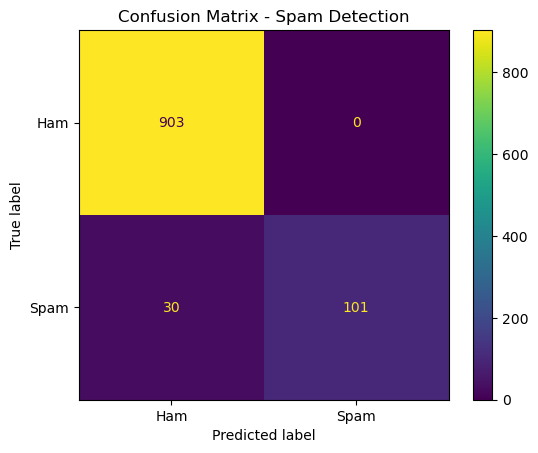

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Confusion Matrix - Spam Detection")
plt.show()

## Model Evaluation & Business Interpretation

The Naive Bayes classification model was evaluated using Accuracy,
Precision, Recall, and F1-Score.

### Evaluation Metrics

- **Accuracy:** Measures the overall percentage of correctly classified
  messages.
- **Precision:** Measures how many messages predicted as spam were
  actually spam.
- **Recall:** Measures how many actual spam messages were correctly
  identified.
- **F1-Score:** Provides a balance between Precision and Recall.

### Business Importance

For a spam detection system, both False Positives and False Negatives
are important.

A **False Positive** occurs when a legitimate message is incorrectly
classified as spam. This can cause users to miss important messages.

A **False Negative** occurs when a spam message is incorrectly
classified as legitimate. This allows unwanted messages to reach users.

Therefore, the business should maintain a good balance between
Precision and Recall.

## Conclusion

This case study used a supervised Machine Learning approach to classify
SMS messages as Spam or Ham.

The SMS Spam Collection dataset was cleaned and transformed using
TF-IDF vectorization. A Multinomial Naive Bayes model was then trained
to classify messages.

The model was evaluated using Accuracy, Precision, Recall, and
F1-Score, along with a Confusion Matrix.

This system can help messaging platforms automatically identify
unwanted messages and improve the user experience.

Future improvements could include testing models such as Logistic
Regression, Support Vector Machines, or ensemble methods and comparing
their performance.